In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [44]:
df=pd.read_csv("/enhanced_zomato_dataset_clean.csv")

In [45]:
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,...,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1.0,0.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1.0,0.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1.0,0.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1.0,0.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,...,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1.0,0.0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79162 entries, 0 to 79161
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Restaurant_Name        79162 non-null  object 
 1   Dining_Rating          79162 non-null  float64
 2   Delivery_Rating        79162 non-null  float64
 3   Dining_Votes           79162 non-null  int64  
 4   Delivery_Votes         79162 non-null  int64  
 5   Cuisine                79162 non-null  object 
 6   Place_Name             79162 non-null  object 
 7   City                   79162 non-null  object 
 8   Item_Name              79162 non-null  object 
 9   Best_Seller            79162 non-null  object 
 10  Votes                  79162 non-null  int64  
 11  Prices                 79162 non-null  float64
 12  Average_Rating         79162 non-null  float64
 13  Total_Votes            79162 non-null  int64  
 14  Price_per_Vote         79162 non-null  float64
 15  Lo

In [47]:
numeric_cols = ['Dining_Rating', 'Delivery_Rating', 'Prices', 'Total_Votes']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [48]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
stats = df[numerical_cols].agg(['mean', 'median', lambda x: x.mode().iloc[0], 'std', 'var'])
print(stats)

          Dining_Rating  Delivery_Rating  Dining_Votes  Delivery_Votes  \
mean           3.827513         3.973359    154.636795      122.771153   
median         3.822264         4.000000     31.000000        0.000000   
<lambda>       3.822264         4.100000      0.000000        0.000000   
std            0.357391         0.239930    237.831925      250.721821   
var            0.127728         0.057567  56564.024345    62861.431440   

                 Votes        Prices  Average_Rating   Total_Votes  \
mean         25.663942    250.675293        3.900436    277.407948   
median        0.000000    219.000000        3.911132    164.000000   
<lambda>      0.000000    200.000000        4.000000      0.000000   
std         141.959717    198.630245        0.237875    300.149352   
var       20152.561348  39453.974341        0.056585  90089.633654   

          Price_per_Vote  Log_Price  Is_Bestseller  Restaurant_Popularity  \
mean          163.215533   5.308277            1.0       

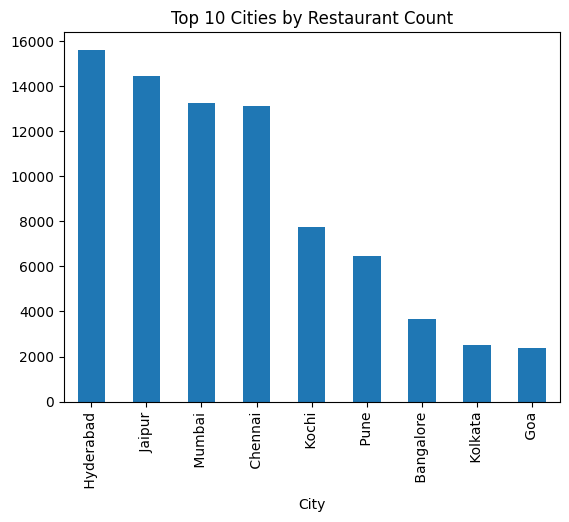

In [49]:
df['City'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cities by Restaurant Count')
plt.show()

In [50]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
stats = df[numerical_cols].agg(['mean', 'median', lambda x: x.mode().iloc[0], 'std', 'var'])
print(stats)

          Dining_Rating  Delivery_Rating  Dining_Votes  Delivery_Votes  \
mean           3.827513         3.973359    154.636795      122.771153   
median         3.822264         4.000000     31.000000        0.000000   
<lambda>       3.822264         4.100000      0.000000        0.000000   
std            0.357391         0.239930    237.831925      250.721821   
var            0.127728         0.057567  56564.024345    62861.431440   

                 Votes        Prices  Average_Rating   Total_Votes  \
mean         25.663942    250.675293        3.900436    277.407948   
median        0.000000    219.000000        3.911132    164.000000   
<lambda>      0.000000    200.000000        4.000000      0.000000   
std         141.959717    198.630245        0.237875    300.149352   
var       20152.561348  39453.974341        0.056585  90089.633654   

          Price_per_Vote  Log_Price  Is_Bestseller  Restaurant_Popularity  \
mean          163.215533   5.308277            1.0       

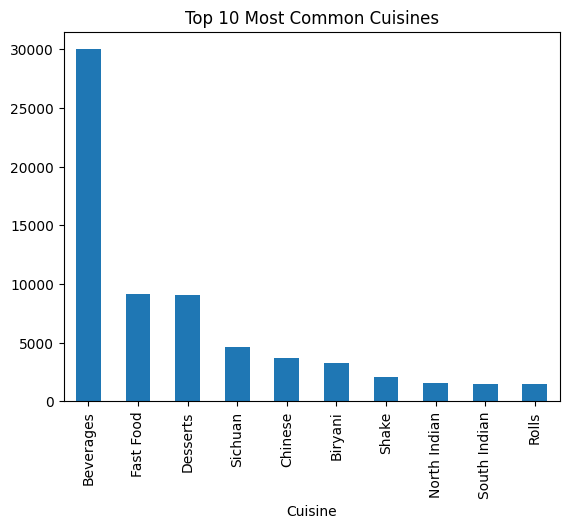

In [51]:
top_cuisines = df['Cuisine'].value_counts().head(10)
top_cuisines.plot(kind='bar')
plt.title('Top 10 Most Common Cuisines')
plt.show()

Skewness of Rating: -0.5866700784673362


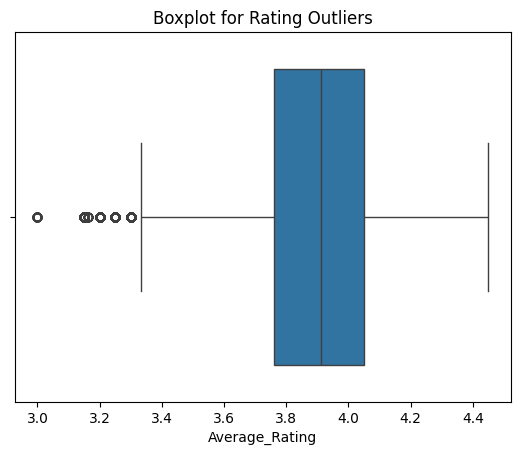

In [52]:
print("Skewness of Rating:", df['Average_Rating'].skew())
sns.boxplot(x=df['Average_Rating'])
plt.title('Boxplot for Rating Outliers')
plt.show()

In [53]:
delivery_comp = df.groupby('Is_Highly_Rated')['Average_Rating'].mean() # Using existing rating flags
print(delivery_comp)

Is_Highly_Rated
0.0    3.761568
1.0    4.116294
Name: Average_Rating, dtype: float64


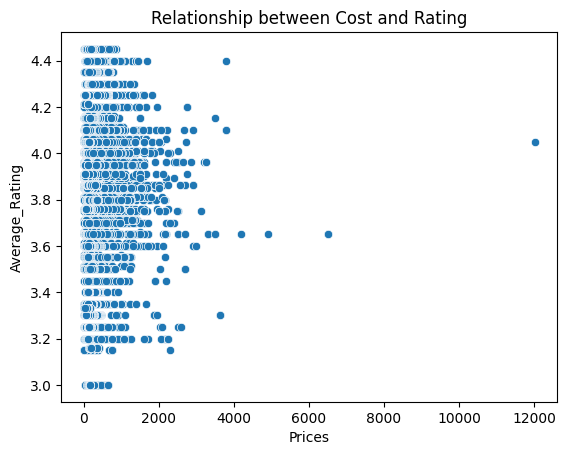

In [54]:
sns.scatterplot(x='Prices', y='Average_Rating', data=df)
plt.title('Relationship between Cost and Rating')
plt.show()

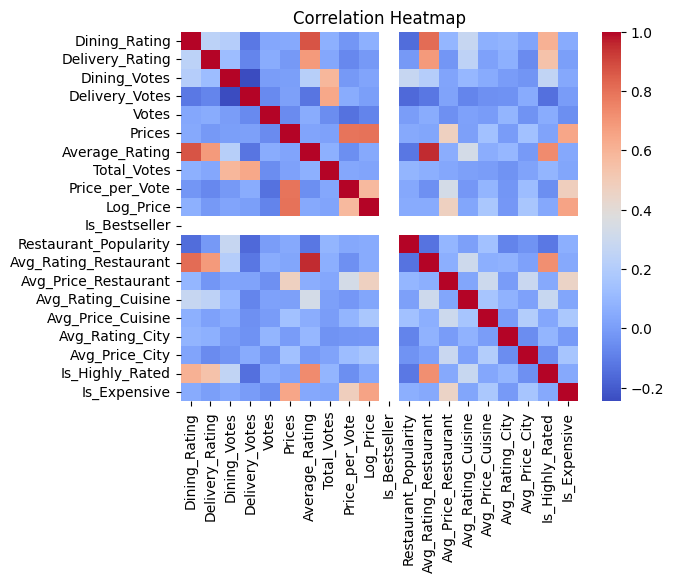

In [55]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [56]:
df['Cost_Category'] = pd.cut(df['Prices'], bins=[0, 300, 600, 1000, float('inf')],
                             labels=['Budget', 'Moderate', 'Premium', 'Luxury'])
df['Rating_Category'] = pd.cut(df['Average_Rating'], bins=[0, 3, 4, 4.5, 5],
                               labels=['Poor', 'Average', 'Good', 'Excellent'])

In [57]:
# Aggregate data to find actionable trends
insights = df.groupby('City')['Average_Rating'].mean().sort_values(ascending=False)
print(insights.head())

City
Kolkata      3.986488
Hyderabad    3.939031
Goa          3.898374
Pune         3.893923
Jaipur       3.892180
Name: Average_Rating, dtype: float64
